In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm

from generate_2k_grid_primitives import generate_and_save_2k_primitives
from save_primitives_to_file import central_symmetry, y_axis_symmetry, write_metadata, save_primitive
from trajectory_optimization import optimization_Newton 

import sys
sys.path.append("../common/")
from DO_structs import *
from DO_graphics import *

%matplotlib inline  

## Define Heading Discretization & Setup Metadata

In [2]:
# Base angles
alpha = np.arctan(1 / 2)
beta = np.arctan(2)

# Define a standard 16-angle orientation grid, widely used in lattice planners 
# to balance angular resolution and computational efficiency.
list_theta_16 = [
    # 0..3
    0.0,
    alpha,
    np.deg2rad(2 / 16 * 360),
    beta,
    # 4..7
    np.deg2rad(4 / 16 * 360),
    alpha + np.pi / 2,
    np.deg2rad(6 / 16 * 360),
    beta + np.pi / 2,
    # 8..11
    np.deg2rad(8 / 16 * 360),
    alpha + np.pi,
    np.deg2rad(10 / 16 * 360),
    beta + np.pi,
    # 12..15
    np.deg2rad(12 / 16 * 360),
    alpha + np.pi / 2 + np.pi,
    np.deg2rad(14 / 16 * 360),
    beta + np.pi / 2 + np.pi,
]

theta_16 = Theta(list_theta_16)

In [3]:
file = "../data/control_set.txt"
extended_file = "../data/extended_set.txt"

write_metadata(file, theta_16)
write_metadata(extended_file, theta_16)

## Configure Goal States for Primitives

In [4]:
# 1. Primitives goals for Cardinal directions (0, 90, 180, 270 degrees)
straight = [
    (State(x=8.0, y=0.0, theta=theta_16[0]), False),
    (State(x=1.0, y=0.0, theta=theta_16[0]), True),
    
    (State(x=5.0, y=5.0, theta=theta_16[4]), True),
    (State(x=8.0, y=1.0, theta=theta_16[1]), False),
    (State(x=8.0, y=2.0, theta=theta_16[2]), False),
    (State(x=6.0, y=5.0, theta=theta_16[3]), True),
    (State(x=7.0, y=4.0, theta=theta_16[3]), False),
    (State(x=6.0, y=1.0, theta=theta_16[1]), True),
    (State(x=7.0, y=3.0, theta=theta_16[2]), True),

    (State(x=5.0, y=-5.0, theta=theta_16[-4]), True),
    (State(x=8.0, y=-1.0, theta=theta_16[-1]), False),
    (State(x=8.0, y=-2.0, theta=theta_16[-2]), False),
    (State(x=6.0, y=-5.0, theta=theta_16[-3]), True),
    (State(x=7.0, y=-4.0, theta=theta_16[-3]), False),
    (State(x=6.0, y=-1.0, theta=theta_16[-1]), True),
    (State(x=7.0, y=-3.0, theta=theta_16[-2]), True),
    
    (State(x=3.0, y=1.0, theta=theta_16[2]), True),
    (State(x=3.0, y=2.0, theta=theta_16[3]), True),
    (State(x=3.0, y=-1.0, theta=theta_16[-2]), True),
    (State(x=3.0, y=-2.0, theta=theta_16[-3]), True),
    (State(x=7.0, y=2.0, theta=theta_16[1]), True),
    (State(x=7.0, y=-2.0, theta=theta_16[-1]), True),
    (State(x=5.0, y=2.0, theta=theta_16[2]), True),
    (State(x=5.0, y=-2.0, theta=theta_16[-2]), True),
]

# 2. Diagonal directions (45, 135, 225, 315 degrees)
diagonal = [
    (State(x=6.0, y=6.0, theta=theta_16[2]), False),
    (State(x=1.0, y=1.0, theta=theta_16[2]), True),

    (State(x=0.0, y=7.0, theta=theta_16[6]), True), 
    (State(x=5.0, y=6.0, theta=theta_16[3]), True), 
    (State(x=4.0, y=7.0, theta=theta_16[4]), True), 
    (State(x=1.0, y=7.0, theta=theta_16[5]), True), 
    (State(x=2.0, y=7.0, theta=theta_16[5]), False),
    (State(x=4.0, y=5.0, theta=theta_16[3]), True), 
    (State(x=3.0, y=7.0, theta=theta_16[4]), False),

    (State(x=7.0, y=0.0, theta=theta_16[-2]), True), 
    (State(x=6.0, y=5.0, theta=theta_16[1]), True), 
    (State(x=7.0, y=4.0, theta=theta_16[0]), True), 
    (State(x=7.0, y=1.0, theta=theta_16[-1]), True), 
    (State(x=7.0, y=2.0, theta=theta_16[-1]), False),
    (State(x=5.0, y=4.0, theta=theta_16[1]), True), 
    (State(x=7.0, y=3.0, theta=theta_16[0]), False),

    (State(x=1.0, y=3.0, theta=theta_16[4]), True), 
    (State(x=1.0, y=4.0, theta=theta_16[5]), True), 
    (State(x=3.0, y=1.0, theta=theta_16[0]), True), 
    (State(x=4.0, y=1.0, theta=theta_16[-1]), True), 
    (State(x=4.0, y=6.0, theta=theta_16[3]), False),
    (State(x=6.0, y=4.0, theta=theta_16[1]), False),
    (State(x=2.0, y=5.0, theta=theta_16[4]), True), 
    (State(x=5.0, y=2.0, theta=theta_16[0]), True), 
]

# 3. Remaining 8 directions (e.g., arctan(1/2))
intermediate = [
    (State(x=8.0, y=4.0, theta=theta_16[1]), False),
    (State(x=2.0, y=1.0, theta=theta_16[1]), True),
    
    (State(x=2.0, y=7.0, theta=theta_16[5]), True),
    (State(x=7.0, y=5.0, theta=theta_16[2]), False),
    (State(x=6.0, y=5.0, theta=theta_16[3]), False),
    (State(x=3.0, y=7.0, theta=theta_16[4]), True),
    (State(x=4.0, y=7.0, theta=theta_16[4]), False),
    (State(x=5.0, y=4.0, theta=theta_16[2]), True),
    (State(x=5.0, y=6.0, theta=theta_16[3]), True),
    
    (State(x=7.0, y=-1.0, theta=theta_16[13]), True),
    (State(x=8.0, y=3.0, theta=theta_16[0]), False),
    (State(x=8.0, y=2.0, theta=theta_16[15]), False),
    (State(x=8.0, y=-1.0, theta=theta_16[14]), False),
    (State(x=8.0, y=1.0, theta=theta_16[14]), True),
    (State(x=6.0, y=2.0, theta=theta_16[0]), True),
    (State(x=8.0, y=0.0, theta=theta_16[15]), True),
    
    (State(x=2.0, y=2.0, theta=theta_16[3]), True),
    (State(x=2.0, y=3.0, theta=theta_16[4]), True),
    (State(x=3.0, y=0.0, theta=theta_16[15]), True),
    (State(x=4.0, y=-0.0, theta=theta_16[14]), True),
    (State(x=5.0, y=5.0, theta=theta_16[2]), True),
    (State(x=7.0, y=1.0, theta=theta_16[0]), True),
    (State(x=4.0, y=4.0, theta=theta_16[3]), True),
    (State(x=5.0, y=0.0, theta=theta_16[15]), True),
]

goals = [straight, diagonal, intermediate]
starts = [State(x=0, y=0, theta=theta_16[0]),
          State(x=0, y=0, theta=theta_16[2]),
          State(x=0, y=0, theta=theta_16[1])]

## Generation, File Saving, and Plotting Loop

1. Simultaneously generates base and extended primitive sets.
2. Saves all generated trajectories directly to txt-files.
3. Time Allocation: Computes execution duration (velocity profile) for each primitive.
   Duration is cast to an integer for backward compatibility with 4D planners (i,j,theta,time).
4. Cell Occupancy: Evaluates exact time-occupancy intervals for every map cell 
   traversed along the path to support dynamic obstacle avoidance.

In [5]:
# Helper function
def add_primitive_to_file(prim, extended):
    if not hasattr(add_primitive_to_file, "prim_id"):
        add_primitive_to_file.prim_id = 0
        add_primitive_to_file.prim_extended_id = 0

    save_primitive(extended_file, prim, add_primitive_to_file.prim_extended_id, theta_16)
    add_primitive_to_file.prim_extended_id += 1

    if not extended:  # base primitives also save in extended control set
        save_primitive(file, prim, add_primitive_to_file.prim_id, theta_16)
        add_primitive_to_file.prim_id += 1

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(32, 10), dpi=400)

for i in range(3):
    ax = axes[i]
    ax.set_aspect('equal', adjustable='box')

    for (goal, extended) in tqdm.tqdm(goals[i]):
        # Generate the root primitive via numerical optimization
        steps, traj = optimization_Newton(start=starts[i], goal=goal)
        
        # Style discrimination for extended/base primitive varieties
        c, l = ("purple", "--") if extended else ("#FF8C00", "-")

        # Process 4-fold central symmetry rotation
        for prim in central_symmetry(traj):
            add_primitive_to_file(prim, extended)
            show_trajectory(prim, col=c, linestyle=l, ax=ax)  

        # Process Y-axis reflection for intermediate bundles (e.g., arctan(1/2))
        if i == 2:
            traj2 = y_axis_symmetry(traj)
            for prim in central_symmetry(traj2):
                add_primitive_to_file(prim, extended)
                show_trajectory(prim, col=c, linestyle=l, ax=ax)
    
    # Отрисовка сетки
    draw_grid(ax, xs=-10, ys=-10, xf=10, yf=10, tick_step=2)

plt.tight_layout()
plt.savefig("../media/smooth_control_set.png", transparent=False, bbox_inches='tight', facecolor='white')
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [11:21<00:00, 28.39s/it]


## $2^k$-Connectivity Control Set Generation

To evaluate alternative search paradigms, this section integrates **$2^k$-connectivity** pathfinding into our existing pipeline. Instead of relying solely on complex motion primitives, $2^k$-connectivity samples a dense, radially distributed set of direct lines-of-sight to neighboring grid coordinates based on the branching factor $k$.

To ensure **seamless backward compatibility** with our existing planner infrastructure without modifying its core loop, we wrap these straight-line segments using the exact same motion primitive data and file format structure as before, applying two key conceptual simplifications:

1. **Instantaneous Rotation:** We assume that transitions between headings in a $2^k$-grid are instantaneous (zero turn radius). Consequently, orientation constraints at the path vertices are omitted from the physical kinodynamic model.
2. **Virtual Heading Discretization:** For the existing codebase to parse these trajectories correctly, we formally define a virtual orientation grid consisting of **a single dummy angle ($\theta = 0.0$)**. Every generated $2^k$ primitive is structurally hardcoded to both depart from and arrive at this zero-heading configuration.

The function below simultaneously executes this generator to dump the standardized text files (`primitives_2k_k.txt`) and renders the resulting vector graphs side-by-side.


In [7]:
def plot_connectivity_notebook(ks: list):
    """
    Plots the directional vector graphs for various 2^k setups side-by-side.
    Simultaneously executes the generator to dump text files.
    """
    fig, axes = plt.subplots(1, len(ks), figsize=(4 * len(ks), 4), dpi=300)
    if len(ks) == 1: 
        axes = [axes]

    for ax, k in zip(axes, ks):
        output_file = f"../data/primitives_2k_{k}.txt"
        
        # Run generator and retrieve vectors directly for plotting
        vectors = generate_and_save_2k_primitives(k, output_file)
        
        # Render directional arrows emanating from the center origin (0,0)
        for vx, vy in vectors:
            ax.quiver(0, 0, vx, vy, angles='xy', scale_units='xy', scale=1, 
                      color='teal', alpha=0.7, width=0.011)
            # Mark endpoint targets
            ax.plot(vx, vy, 'o', color='darkred', markersize=4)

        # Environment styling & boundaries
        ax.set_aspect('equal')
        # Assuming draw_grid helper is imported from DO_graphics
        if 'draw_grid' in globals():
            draw_grid(ax, xs=-4, ys=-4, xf=4, yf=4, tick_step=1)
        else:
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.set_xlim(-4.5, 4.5)
            ax.set_ylim(-4.5, 4.5)
            
        ax.set_title(f"$2^{{{k}}}$-connectivity\n({len(vectors)} neighbors)", fontsize=14)

    plt.tight_layout()
    plt.savefig("../media/2k_control_set.png", transparent=False, bbox_inches='tight', facecolor='white')
    plt.show()

Successfully generated 4 primitives for 2^2 connectivity into: ../data/primitives_2k_2.txt
Successfully generated 8 primitives for 2^3 connectivity into: ../data/primitives_2k_3.txt
Successfully generated 16 primitives for 2^4 connectivity into: ../data/primitives_2k_4.txt
Successfully generated 32 primitives for 2^5 connectivity into: ../data/primitives_2k_5.txt


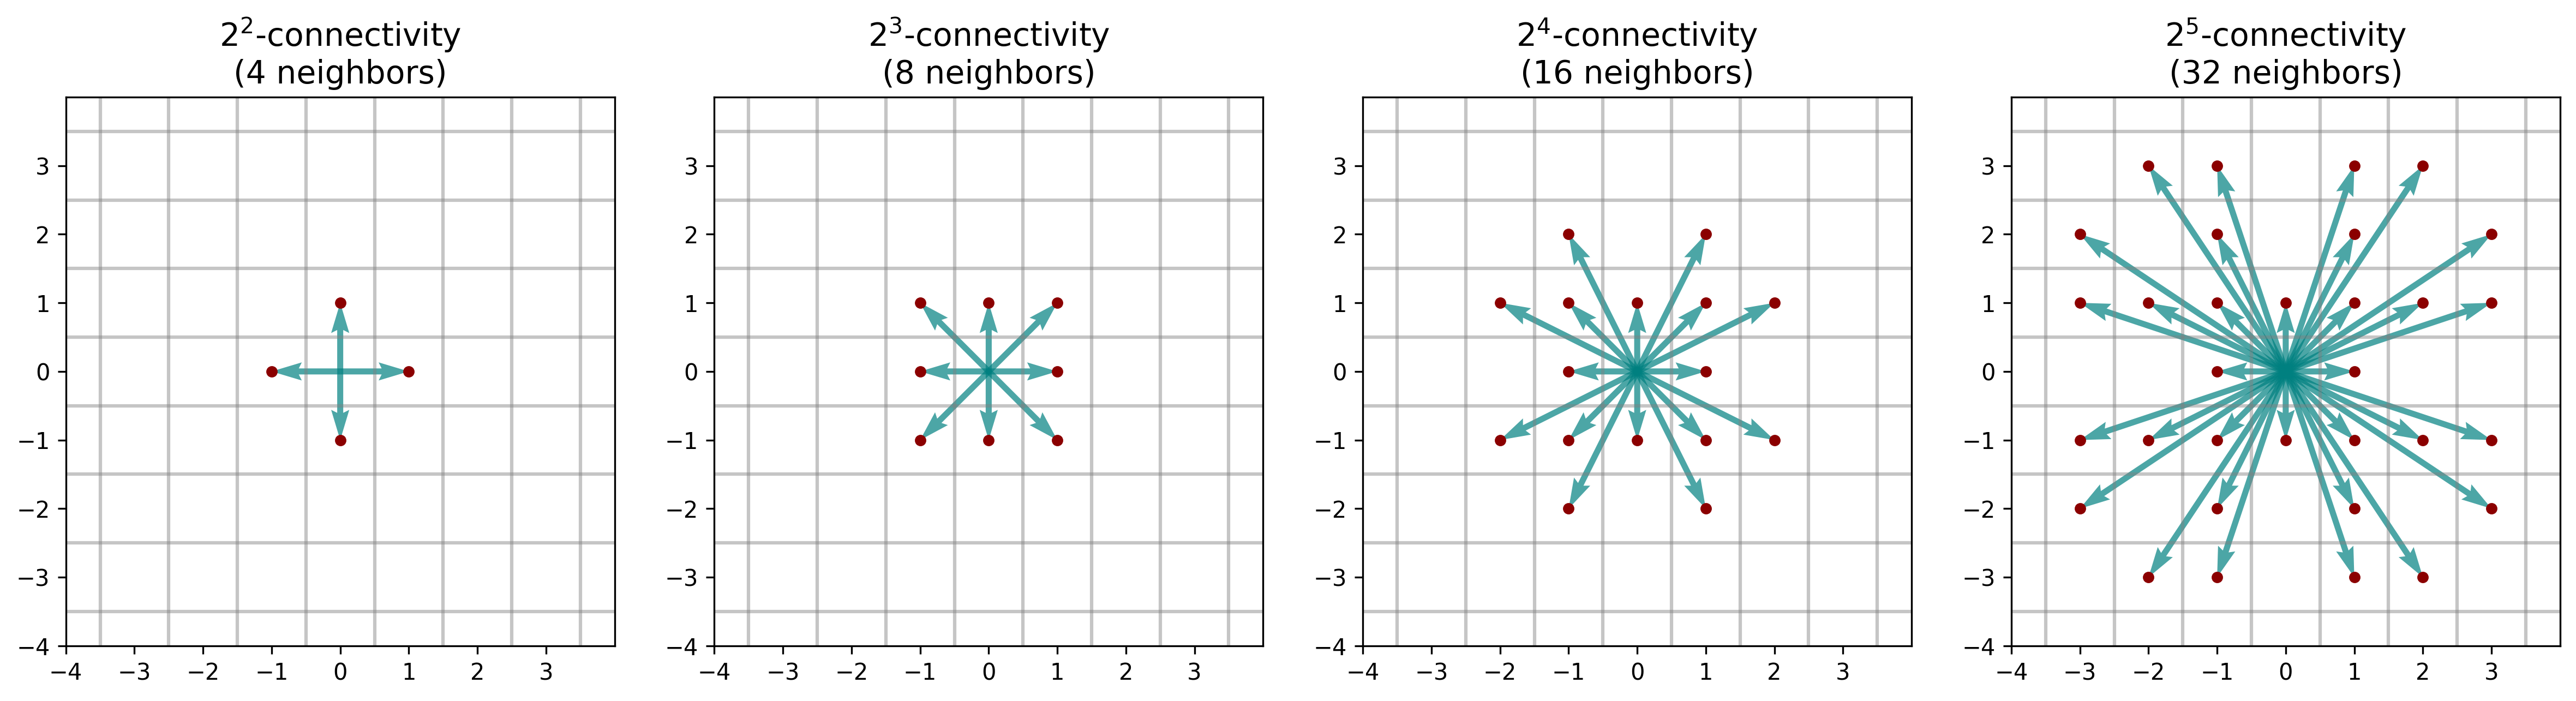

In [8]:
ks_to_plot = [2, 3, 4, 5]
plot_connectivity_notebook(ks_to_plot)